In [1]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 4.1 MB/s eta 0:00:00


In [2]:
import pandas as pd

# Veriyi oku
df = pd.read_csv('train.csv')
print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

1. Adım: Durum Tespiti (Hangi Sütunlar Boş?)
Önce hangi sütunda ne kadar eksik var, onları bir görelim. Bazı sütunlar (örneğin PoolQC) %99 boştur, bazıları ise (örneğin MasVnrArea) sadece birkaç tane eksik içerir.

In [3]:
missing_data = df.isnull().sum()

In [4]:
print(missing_data[missing_data > 0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


2. Adım: Sayısal Verileri Doldurma (Mean/Median)
Sayısal bir sütunda (mesela LotFrontage) veri eksikse,en güvenli yol o sütunun Ortalamasını (Mean) veya Medyanını (Median) kullanmaktır.

In [5]:
from feature_engine.imputation import MeanMedianImputer

# 1. Imputer'ı kuralım (Medyan kullanalım, aykırı değerlere karşı daha güvenlidir)
imputer_num = MeanMedianImputer(imputation_method='median', variables=['LotFrontage', 'MasVnrArea'])

# 2. Uygulayalım
df = imputer_num.fit_transform(df)

  3. Adım: Kategorik Verileri Doldurma (Frequent/Missing)
Eğer bir kategorik sütun (mesela FireplaceQu) boşsa, oraya rastgele bir mahalle ismi yazamayız.iki yol vardır :

En Sık Geçen Değer (Mode): En popüler kategoriyi yazmak.

"Missing" Etiketi: Oraya doğrudan "Kayıt Yok" anlamına gelen bir kelime yazmak (En çok bu tercih edilir).

In [6]:
from feature_engine.imputation import CategoricalImputer

# Kategorik boşluklara "Missing" yazalım
imputer_cat = CategoricalImputer(variables=['Alley', 'FireplaceQu', 'PoolQC'])

# Uygula
df = imputer_cat.fit_transform(df)

Sadece kaç tane eksik olduğunu bilmek yetmez, verinin ne kadarını kapladığını görmeliyiz. Eğer bir sütunun %90'ı boşsa, o sütunu tamir etmek yerine silmek daha mantıklı olabilir.

In [7]:
# Eksik verilerin yüzdesini hesaplayalım
missing_info = df.isnull().mean() * 100
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)

print("Eksik Veri Oranları (%):")
print(missing_info)

Eksik Veri Oranları (%):
MiscFeature     96.301370
Fence           80.753425
MasVnrType      59.726027
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
GarageQual       5.547945
GarageFinish     5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
Electrical       0.068493
dtype: float64


Sayısal ve Kategorik eksiklere farklı davranılır.

Sayısal Sütunlar (Örn: LotFrontage): Evin caddeye bakan cephesidir. Buradaki eksikliği ortalamayla doldurabiliriz.

Kategorik Sütunlar (Örn: Alley): Evin arka yolu olup olmadığını belirtir. Buradaki NaN aslında "Yol Yok" demektir.

In [8]:
vars_with_na = [var for var in df.columns if df[var].isnull().sum() > 0]

cat_na = [var for var in vars_with_na if df[var].dtype == 'O']
num_na = [var for var in vars_with_na if df[var].dtype != 'O']

print(f"Kategorik Eksikler: {len(cat_na)} sütun")
print(f"Sayısal Eksikler: {len(num_na)} sütun")

Kategorik Eksikler: 13 sütun
Sayısal Eksikler: 1 sütun


Eksik veriler rastgele mi dağılmış yoksa birbiriyle bağlantılı mı? (Mesela garajı olmayan bir evin tüm garajla ilgili 5 sütunu da boştur).

Bunu anlamak için missingno kütüphanesi harikadır:

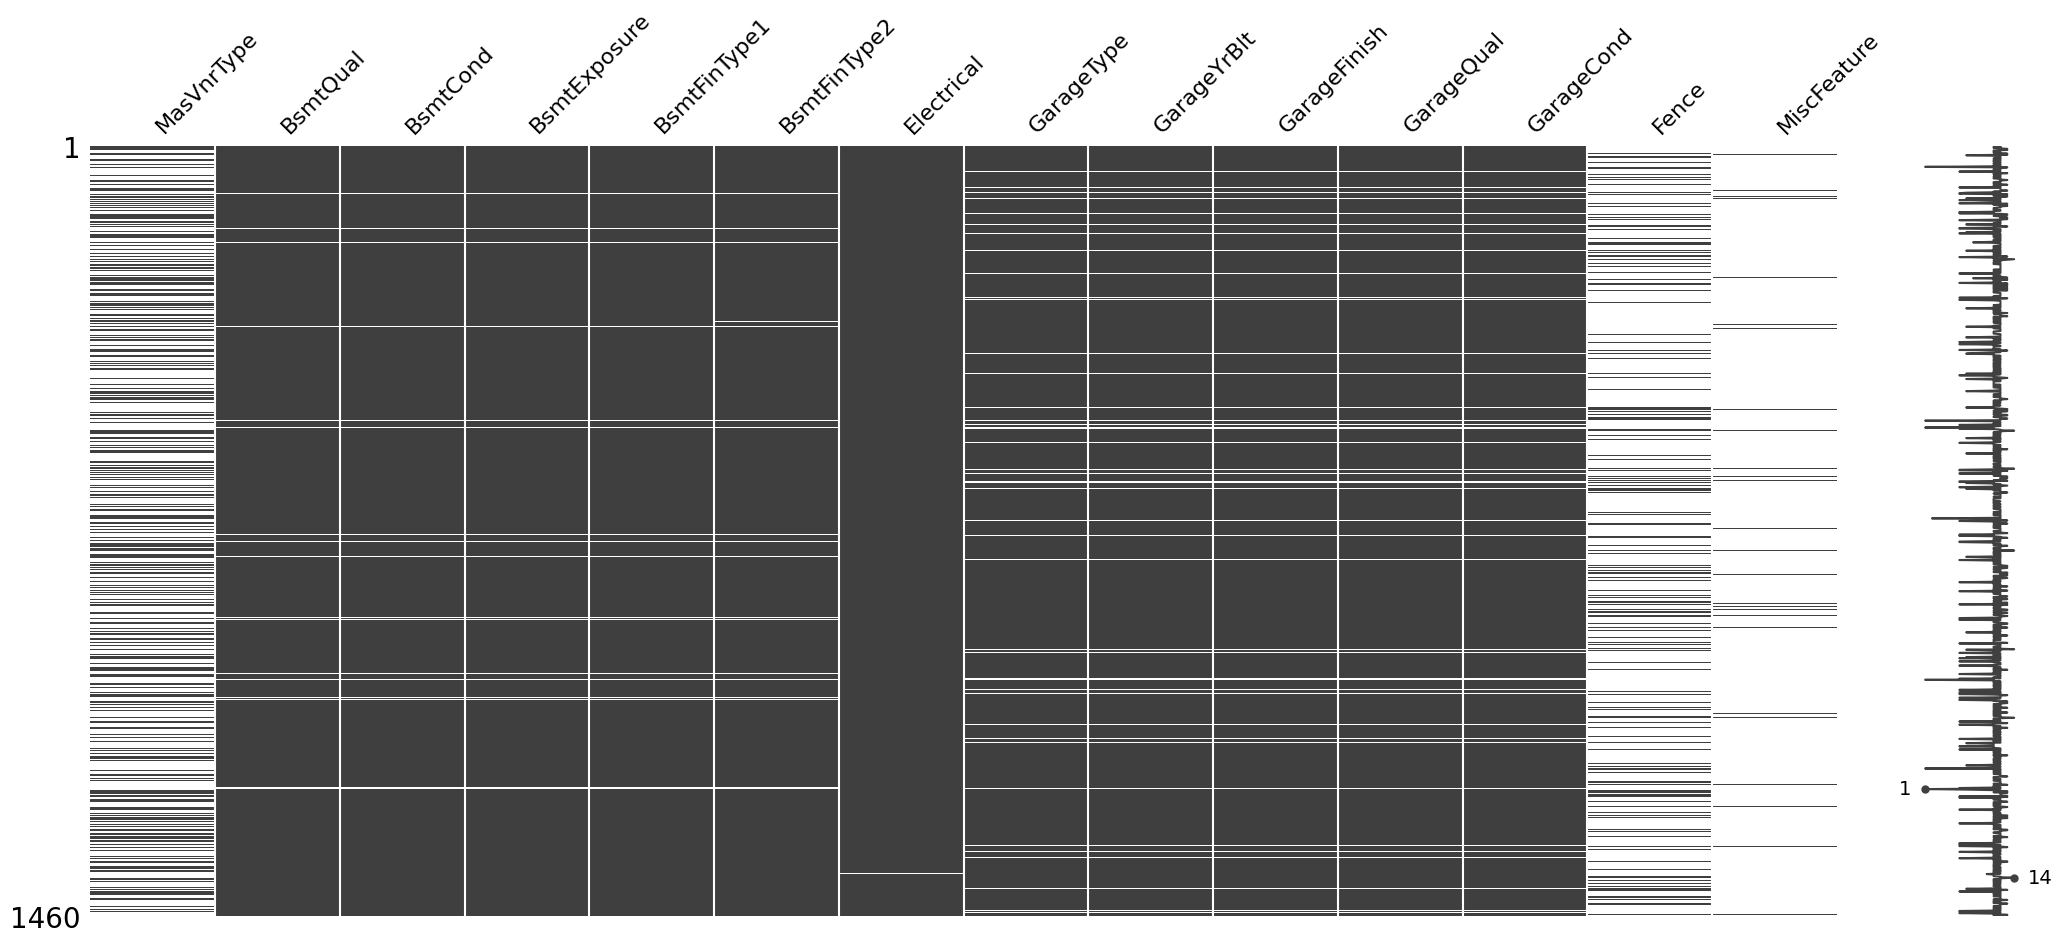

In [9]:
import missingno as msno
import matplotlib.pyplot as plt

# Eksik verilerin matrisini çizelim
msno.matrix(df[vars_with_na])
plt.show()

MiscFeature (%96), Fence (%80) ve MasVnrType (%59) gibi sütunlardaki eksiklikler aslında bir hata değildir.

Mimar Yorumu: Bu evlerin %96'sında ekstra bir özellik (tenis kortu, asansör vb.) yok, %80'inde çit yok.

Strateji: Bu boşlukları silmek yerine "Missing" veya "None" olarak etiketlemeliyiz. Çünkü bir özelliğin "olmaması" da fiyatı etkileyen bir bilgidir.

In [10]:
from feature_engine.imputation import CategoricalImputer

# En çok eksiği olan kategorik sütunları seçelim
cat_vars = ['MiscFeature', 'Fence', 'MasVnrType', 'GarageType',
            'GarageCond', 'GarageQual', 'GarageFinish',
            'BsmtExposure', 'BsmtFinType2', 'BsmtFinType1',
            'BsmtCond', 'BsmtQual']

# Imputer'ı kur (imputation_method='missing' varsayılandır)
cat_imputer = CategoricalImputer(imputation_method='missing', variables=cat_vars)

# Uygula
df = cat_imputer.fit_transform(df)

2. "Bağlantılı" Eksikler (Garaj ve Bodrum Grubu)
Bak dikkat et, Garage... ile başlayan 5 sütunun da eksik oranı aynı: %5.54. Keza Bsmt... (Bodrum) sütunları da birbirine çok yakın.

Mimar Yorumu: Bu evlerin muhtemelen garajı veya bodrumu hiç yok. Biri boşsa hepsi boş kalmış.

Strateji: Bunları gruplayıp aynı anda doldurmalıyız.

In [12]:
from feature_engine.imputation import MeanMedianImputer

# Sayısal olan yıl sütununu medyan (orta değer) ile dolduralım
num_imputer = MeanMedianImputer(imputation_method='median', variables=['GarageYrBlt'])

# Uygula
df = num_imputer.fit_transform(df)

In [13]:
print(df[cat_vars + ['GarageYrBlt']].isnull().sum())

MiscFeature     0
Fence           0
MasVnrType      0
GarageType      0
GarageCond      0
GarageQual      0
GarageFinish    0
BsmtExposure    0
BsmtFinType2    0
BsmtFinType1    0
BsmtCond        0
BsmtQual        0
GarageYrBlt     0
dtype: int64


Grafikteki kutunun dışındaki o küçük noktalar var ya? İşte onlar bizim "aykırı" evlerimiz. Diğerlerinden çok daha büyükler!

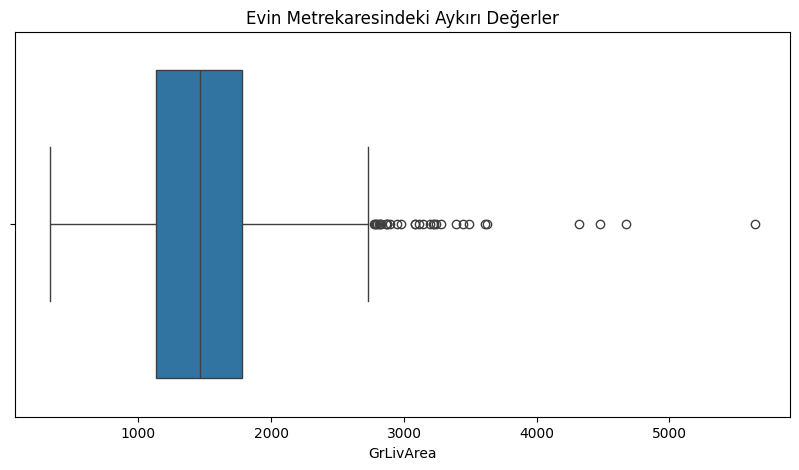

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Kutu grafiği çizdirelim
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['GrLivArea'])
plt.title('Evin Metrekaresindeki Aykırı Değerler')
plt.show()

In [16]:
def find_outliers(df, variable):
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
    lower_bridge = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_bridge = df[variable].quantile(0.75) + (IQR * 1.5)
    return lower_bridge, upper_bridge

lower, upper = find_outliers(df, 'GrLivArea')
print(f"GrLivArea için Alt Sınır: {lower}, Üst Sınır: {upper}")

# Bu sınırların dışındaki verileri sayalım
outliers = df[(df['GrLivArea'] < lower) | (df['GrLivArea'] > upper)]
print(f"Toplam Aykırı Değer Sayısı: {len(outliers)}")

GrLivArea için Alt Sınır: 158.625, Üst Sınır: 2747.625
Toplam Aykırı Değer Sayısı: 31


Bulduğumuz bu uç değerleri silersek veri kaybederiz. Onun yerine kursun en çok sevdiği yöntem olan Capping (Sınırlandırma) işlemini yapalım. Yani o "çok büyük" evleri, belirlediğimiz üst sınıra eşitleyelim.

In [19]:
from feature_engine.outliers import Winsorizer

# Gaussian yöntemini (Ortalamadan 3 standart sapma) kullanalım
# Genellikle sağdaki (yüksek) değerler sorun çıkarır, o yüzden tail='right'
windsor = Winsorizer(capping_method='gaussian', tail='right', fold=3, variables=['GrLivArea', 'SalePrice'])

# Eğit ve Dönüştür
df = windsor.fit_transform(df)

# Kontrol: Maksimum değer düştü mü?
print("Yeni Maksimum GrLivArea:", df['GrLivArea'].max())

Yeni Maksimum GrLivArea: 3091.364879317106


Text(0.5, 1.0, 'Tıraşlama Sonrası (Winsorized)\nGrLivArea')

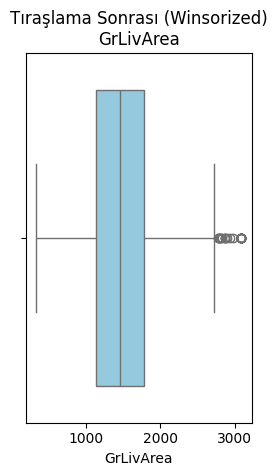

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Grafik: Tıraşlanmış (Winsorized) Veri
plt.subplot(1, 2, 1)
sns.boxplot(x=df['GrLivArea'], color='skyblue')
plt.title('Tıraşlama Sonrası (Winsorized)\nGrLivArea')

Text(0.5, 1.0, 'Dağılımın Yeni Hali')

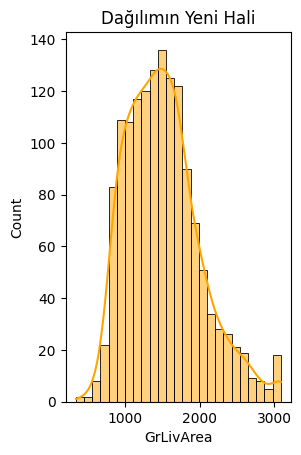

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
# 2. Grafik: Hala aykırı değer var mı bakıyoruz
plt.subplot(1, 2, 2)
sns.histplot(df['GrLivArea'], kde=True, color='orange')
plt.title('Dağılımın Yeni Hali')

In [25]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

In [26]:
# 1. Orijinal Dağılım ve Çarpıklık Katsayısı
original_skew = skew(df['SalePrice'])
print(f"Orijinal Çarpıklık (Skewness): {original_skew:.2f}")

Orijinal Çarpıklık (Skewness): 1.17


In [27]:
# 2. Logaritmik Dönüşüm Uygula
# Not: np.log1p kullanıyoruz (0 değeri varsa hata vermemesi için log(x+1) yapar)
df['SalePrice_Log'] = np.log1p(df['SalePrice'])

In [28]:
# 3. Görselleştirme
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0.5, 1.0, 'Orijinal Dağılım (Skew: 1.17)')

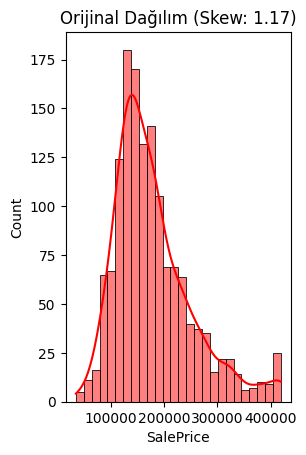

In [29]:
plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True, color="red")
plt.title(f"Orijinal Dağılım (Skew: {original_skew:.2f})")

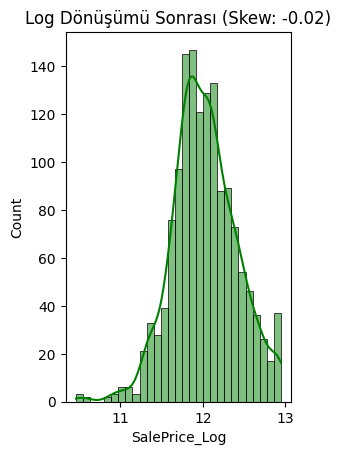

In [30]:
plt.subplot(1, 2, 2)
sns.histplot(df['SalePrice_Log'], kde=True, color="green")
plt.title(f"Log Dönüşümü Sonrası (Skew: {skew(df['SalePrice_Log']):.2f})")

plt.show()